In [2]:
import pickle
import os
path = "/users/astepancic/projects/apertus-probes/scratch/mera-runs/mmlu_high_school/Apertus-8B-Instruct-2509/df_probes_hs.pkl"
# Expand $SCRATCH environment variable if present in the path

with open(path, 'rb') as file:
    results = pickle.load(file)
results.head()


,Dataset,LLM_model,Task,Model,Inputs,Error-Type,Layer,Residuals,Coefficients,Nonzero-Features,No-Coefficients,Attempt,Model-Index,Token-Pos,y_pred,y_test,RMSE,MSE,Dummy-RMSE,Dummy-MSE
0,mmlu_high_school,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[0.21244490146636963, 0.06464040279388428, 1.9...","[11.563600540161133, 0.29036521911621094, -0.2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,1,last,"[1.3475593328475952, 1.0634403228759766, 1.347...","[1.5600042, 0.9987999, -0.63909507, -1.9231397...",4.085407,4.085407,4.114088,4.114088
1,mmlu_high_school,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[0.25477516651153564, 2.223088264465332, 0.294...","[7.947868347167969, 5.8135881423950195, -0.764...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,2,last,"[1.0166980028152466, 0.7744705677032471, -0.17...","[0.76192284, -1.4486177, -0.46863422, 1.581892...",3.980865,3.980865,4.062465,4.062465
2,mmlu_high_school,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[3.5841031074523926, 2.0920279026031494, 0.092...","[8.51669979095459, 4.645131587982178, -0.63516...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,3,last,"[0.9235077500343323, 1.0879719257354736, 1.087...","[4.507611, 3.1799998, 1.1808527, -0.43286678, ...",4.264418,4.264418,3.982965,3.982965
3,mmlu_high_school,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[4.190736770629883, 2.1125524044036865, 0.0402...","[2.0381762981414795, 0.5923985242843628, 0.495...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,4,last,"[-0.027781188488006592, 0.8494377136230469, 1....","[4.1629558, 2.96199, 1.7146045, 2.9116998, 1.4...",3.695322,3.695322,4.040802,4.040802
4,mmlu_high_school,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[2.0907704830169678, 0.1931666135787964, 3.260...","[4.650482177734375, 6.726263046264648, -0.2856...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,5,last,"[0.8808732032775879, 1.2570823431015015, -0.10...","[-1.2098973, 1.0639157, -3.3608732, 0.31745327...",3.825768,3.825768,3.756279,3.756279


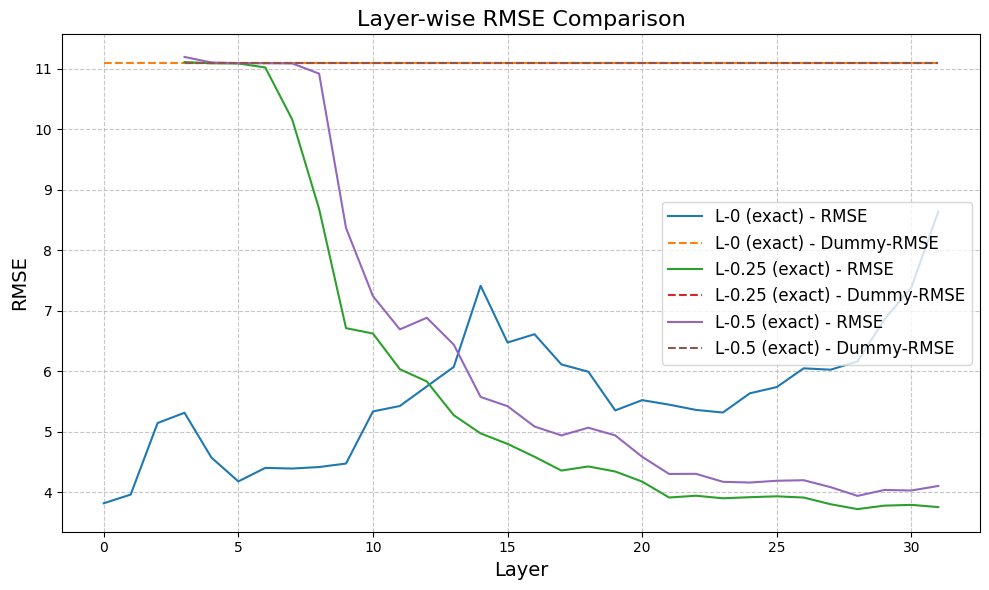

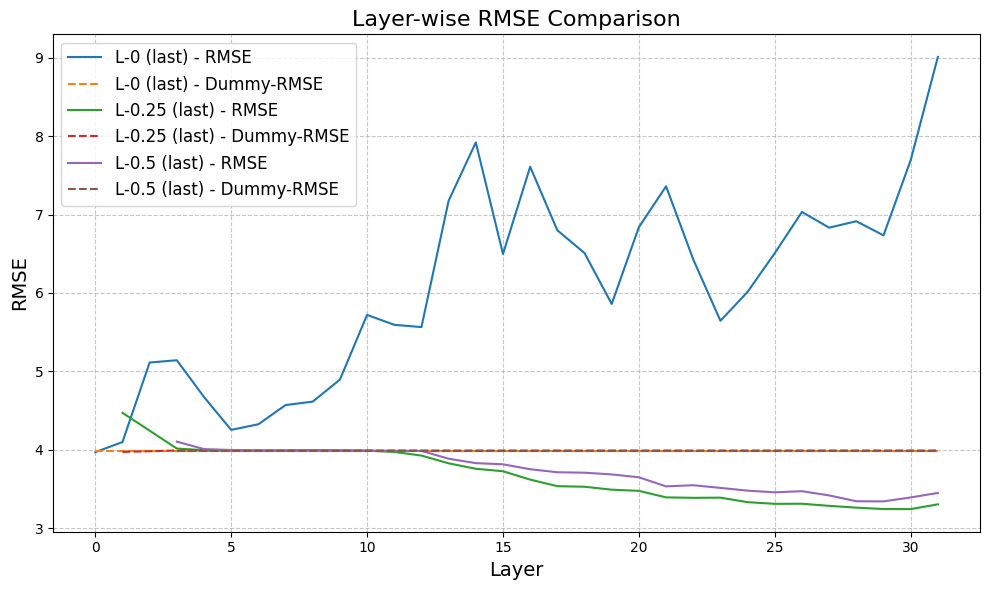

In [3]:
import matplotlib.pyplot as plt

# Define a function to plot RMSE for multiple models or token positions in one figure
def plot_rmse_comparison(grouped_data, models_to_plot, token_positions):
    plt.figure(figsize=(10, 6))

    for model in models_to_plot:
        for token_pos in token_positions:
            # Filter data for the specific model and token position
            group = grouped_data[(grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)]
            
            # Group by 'Layer' and calculate the mean RMSE
            layer_averages = group.groupby('Layer')[['RMSE', "Dummy-RMSE"]].mean()
            # Plot RMSE for the current model and token position
            plt.plot(
                layer_averages.index,
                layer_averages['RMSE'],
                label=f'{model} ({token_pos}) - RMSE'
            )
            
            # Plot Dummy-RMSE for the current model and token position
            plt.plot(
                layer_averages.index,
                layer_averages['Dummy-RMSE'],
                linestyle='--',  # Dashed line for Dummy-RMSE
                label=f'{model} ({token_pos}) - Dummy-RMSE'
            )

    # Add labels, title, and legend
    plt.title('Layer-wise RMSE Comparison', fontsize=16)
    plt.xlabel('Layer', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage
models_to_plot = ['L-0', 'L-0.25', 'L-0.5']
token_positions = ['exact'] # Replace with actual token positions
plot_rmse_comparison(results, models_to_plot, token_positions)
token_positions = ['last']
plot_rmse_comparison(results, models_to_plot, token_positions)
